# Global Superstore Sales Analysis

**Dataset:** Global Superstore (57,809 rows, 24 columns)

**Tools:** Python, Pandas, Matplotlib

**Goal:** Exploratory Data Analysis to uncover sales, profit, and shipping trends

## Business Questions
1. Which year had the highest sales?
2. Which market is most profitable?
3. Which category drives the most revenue?
4. Does discount lead to loss in profit?
5. Which ship mode is used the most?

In [ ]:
import pandas as pd


df = pd.read_csv('Global_Superstore2.csv', encoding='latin-1' , on_bad_lines='skip')


df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')


df.drop(columns=['Postal Code'], inplace=True)


df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month


df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df.drop_duplicates(inplace=True)

print(df.shape)
print(df.columns.tolist())

(51290, 26)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Order Year', 'Order Month', 'Shipping Days']


##  Year with the Highest Sales
Group of total sales in each year to identify growth trends across 2011–2014.

In [ ]:
import matplotlib.pyplot as plt

yearly_sales = df.groupby('Order Year')['Sales'].sum()
print(yearly_sales)

Order Year
2011.0    2.252972e+06
2012.0    2.670244e+06
2013.0    3.397700e+06
2014.0    4.288587e+06
Name: Sales, dtype: float64


**Finding:** Sales grew consistently every year. 2014 recorded the highest sales at ~$4.3M, indicating strong and steady business growth throughout this period.

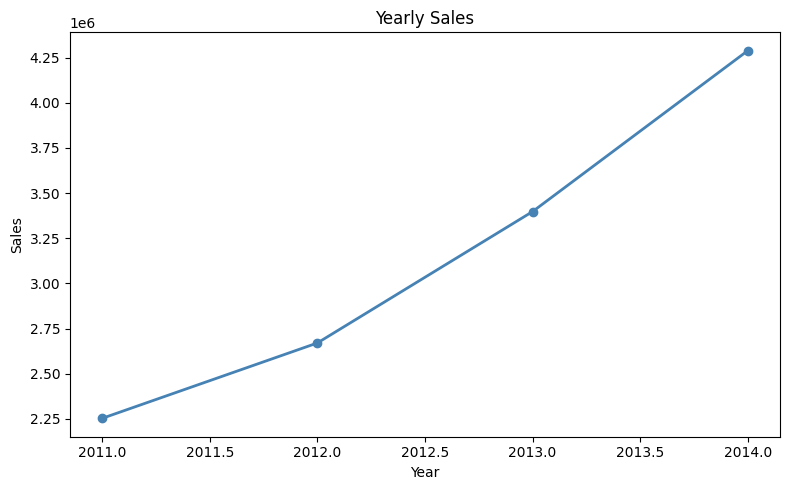

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

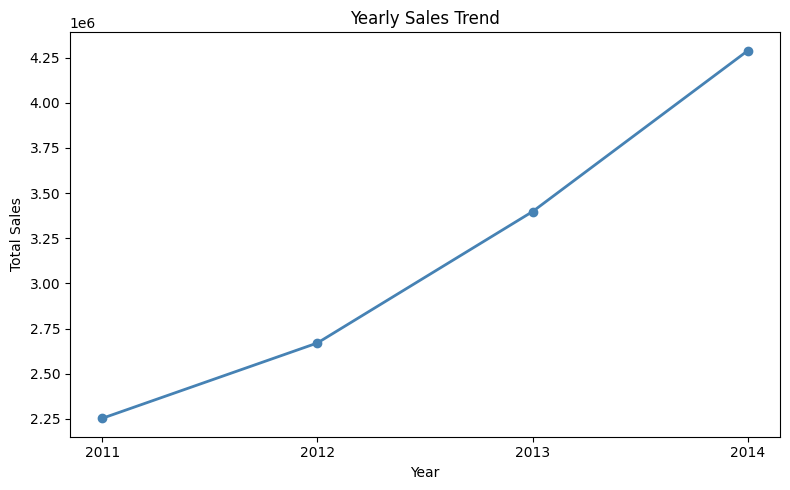

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks([2011, 2012, 2013, 2014])
plt.tight_layout()
plt.show()

## Top Selling Products

In [ ]:
product_sales = df.groupby('Product Name')['Sales'].sum()

product_sales = product_sales.sort_values(ascending=False).head(10)

print(product_sales)

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64


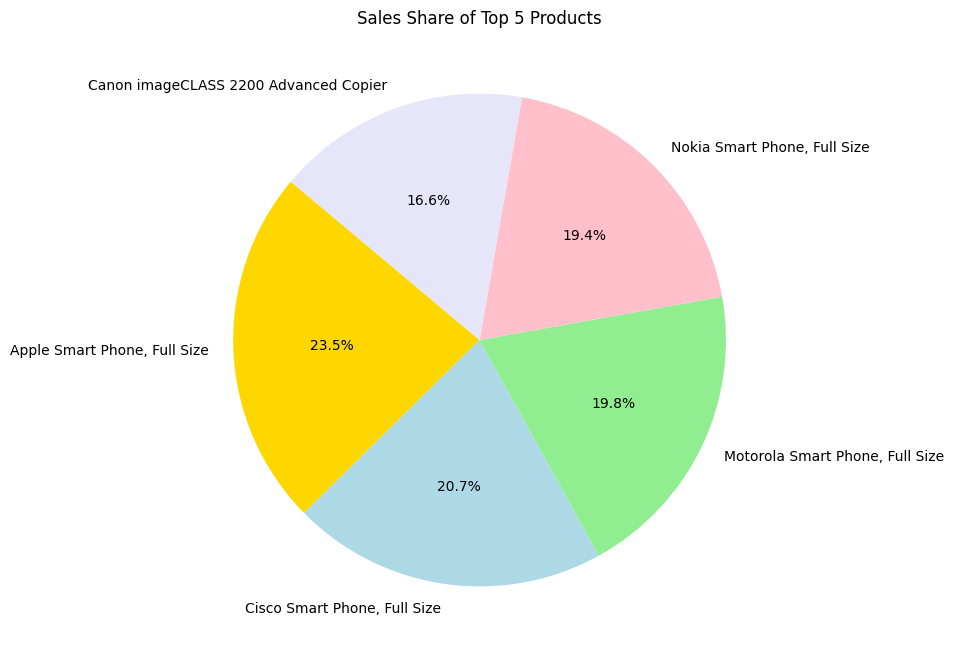

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 8))


plt.pie(product_sales.head(5).values,
        labels=product_sales.head(5).index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['gold', 'lightblue', 'lightgreen', 'pink', 'lavender'])


plt.title('Sales Share of Top 5 Products')


plt.show()

##Category Driving the Most Revenue
grouping by total sales to see which of the product categories generates the most revenue.

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


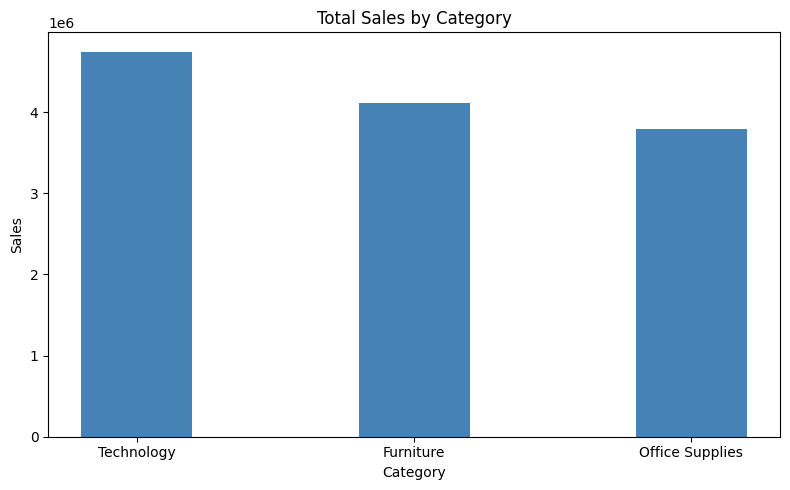

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values, color='steelblue', width=0.4)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## Discount Lead to Loss / Profit
The dashed line at 0 separates profitable orders (above) from loss-making orders (below).

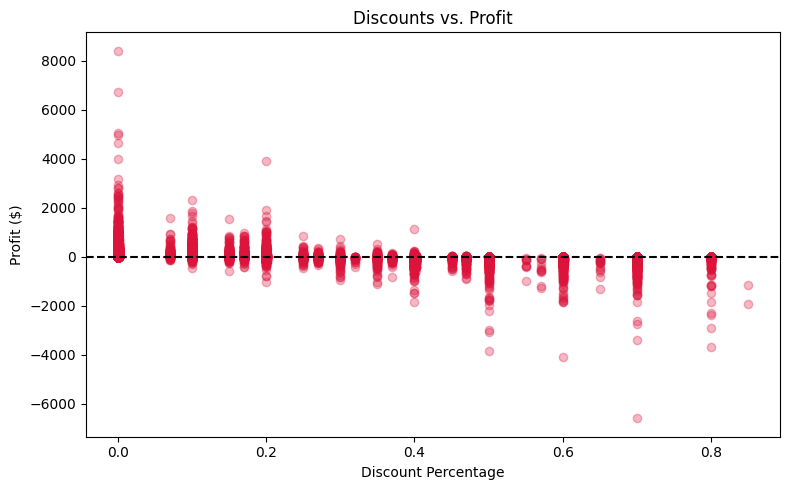

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='crimson')


plt.title('Discounts vs. Profit')
plt.xlabel('Discount Percentage')
plt.ylabel('Profit ($)')


plt.axhline(0, color='black', linestyle='--')


plt.tight_layout()
plt.show()

## Ship Mode
frequency of each shipping mode to understand customer and operational shipping preferences.



In [ ]:

shipping_counts = df['Ship Mode'].value_counts()
print(shipping_counts)

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64


In [ ]:
print(df.groupby('Market')['Profit'].sum())
print("---")
print(df.groupby('Region')['Profit'].sum())

Market
APAC      436000.04900
Africa     88871.63100
Canada     17817.39000
EMEA       43897.97100
EU        372829.74150
LATAM     221643.48708
US        286397.02170
Name: Profit, dtype: float64
---
Region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           120089.11200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: Profit, dtype: float64


In [ ]:
market_profit = df.groupby('Market')['Profit'].sum().sort_values(ascending=False)
print(market_profit)



Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64


## Total Profit(market)
  total profit by sales in different markets

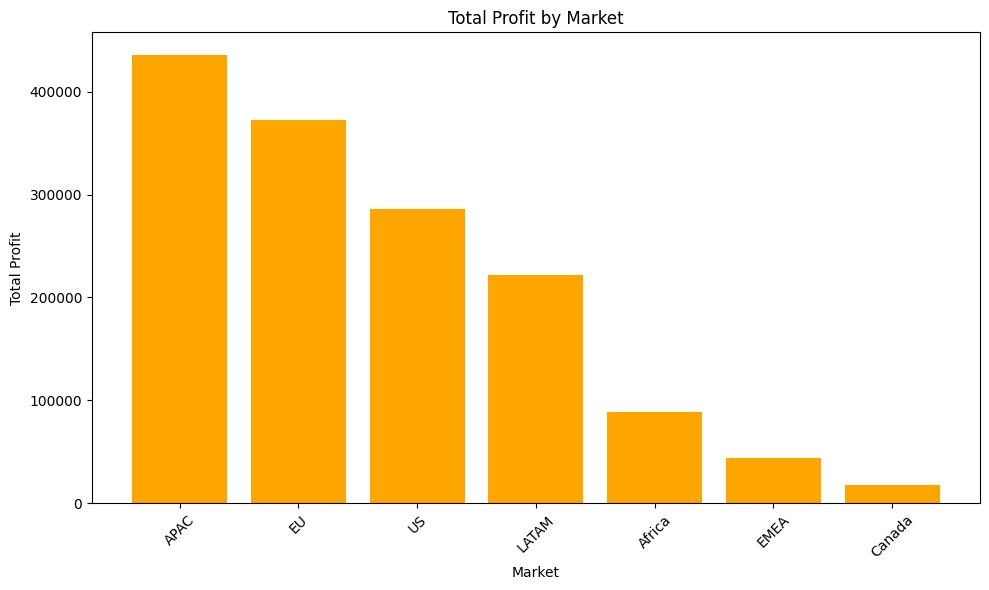

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(market_profit.index, market_profit.values, color='orange')
plt.title('Total Profit by Market')
plt.xlabel('Market')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()